# SINet Single-Image Prediction

Use this notebook to instantiate SINet, run prediction on one image, and compare the original image with the predicted camouflaged-object mask.

## 1. Imports and Paths

Before running this notebook, download the pretrained checkpoint and place it at `Snapshot/2020-CVPR-SINet/SINet_40.pth`.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

from Src.SINet import SINet_ResNet50

CHECKPOINT_PATH = Path("Snapshot/2020-CVPR-SINet/My-SINet_40.pth")
IMAGE_PATH = Path("/Users/felix/Desktop/SINet/Dataset/TestDataset/CAMO/Imgs/camourflage_00857.jpg")
GT_PATH = Path("/Users/felix/Desktop/SINet/Dataset/TestDataset/CAMO/GT/camourflage_00857.png"   )
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Checkpoint exists:", CHECKPOINT_PATH.exists())
print("Image exists:", IMAGE_PATH.exists())
print("Ground truth exists:", GT_PATH.exists())

Device: cpu
Checkpoint exists: True
Image exists: True
Ground truth exists: True


## 2. Helper Functions

In [8]:
from collections import OrderedDict

def build_sinet(checkpoint_path=CHECKPOINT_PATH, device=DEVICE):
    if not Path(checkpoint_path).exists():
        raise FileNotFoundError(
            f"Checkpoint not found: {checkpoint_path}. "
            "Download SINet_40.pth and place it there first."
        )

    model = SINet_ResNet50(pretrained=False).to(device)
    state_dict = torch.load(checkpoint_path, map_location=device)

    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace("module.", "", 1)
        new_state_dict[name] = v

    model.load_state_dict(new_state_dict)
    model.eval()
    return model


def preprocess_image(image_path, testsize=352):
    """Load an RGB image and convert it into the normalized SINet input tensor."""
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((testsize, testsize)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])
    return image, transform(image).unsqueeze(0)


def predict_mask(model, image_tensor, original_size, device=DEVICE):
    """Predict a normalized mask with the same height and width as the original image."""
    image_tensor = image_tensor.to(device)
    height, width = original_size

    with torch.no_grad():
        _, cam = model(image_tensor)
        # Upsample the CAM to the original image size and apply sigmoid to get values in [0, 1]
        cam = F.interpolate(cam, size=(height, width), mode="bilinear", align_corners=True)
        cam = torch.sigmoid(cam).cpu().numpy().squeeze()

    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8) # Normalize to [0, 1]


def show_prediction_comparison(image, mask, alpha=0.45):
    """Show original image, predicted mask, and a heatmap overlay side by side."""
    image_np = np.asarray(image)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image_np)
    axes[0].set_title("Original image")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Predicted mask")

    axes[2].imshow(image_np)
    axes[2].imshow(mask, cmap="jet", alpha=alpha)
    axes[2].set_title("Overlay")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 3. Run Prediction and Compare

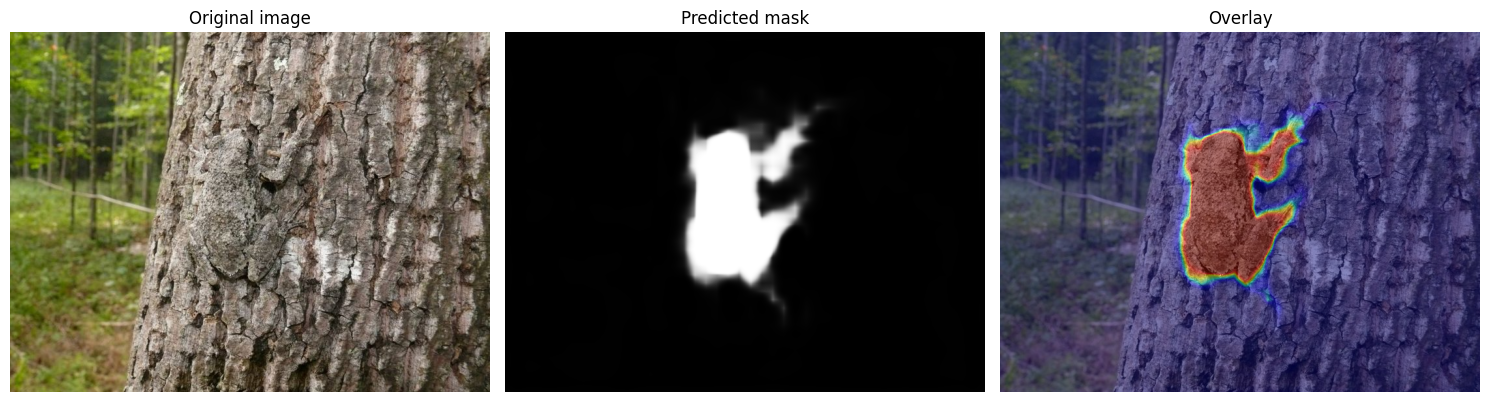

In [9]:
model = build_sinet()
original_image, input_tensor = preprocess_image(IMAGE_PATH)
mask = predict_mask(
    model,
    input_tensor,
    original_size=(original_image.height, original_image.width),
)

show_prediction_comparison(original_image, mask)